In [389]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", message=".*no associated frequency.*")

In [390]:
df = pd.read_excel("../merged_data.xlsx",) 

In [391]:
df.head()

,date,day,time,jay,dheeraj,shashi,total,dheeraj_hours,shashi_hours,tips: shashi,...,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny,sunny_hours,siddharth,atharv,atharv_hours
0,2025-04-01,Tuesday,11 TO 8,306.0,NaN,NaN,306.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-02,Wednesday,11 TO 8,NaN,117.0,NaN,117.0,5.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-03,Thursday,11 TO 8,405.0,NaN,NaN,405.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-04-04,Friday,11 TO 9,NaN,650.0,NaN,650.0,5.5,9.0,2.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-05,Saturday,10 TO 9,NaN,615.0,NaN,615.0,10.0,6.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [392]:
df.shape

(1023, 26)

In [393]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1005 non-null   datetime64[ns]
 1   day                    1006 non-null   object        
 2   time                   981 non-null    object        
 3   jay                    187 non-null    float64       
 4   dheeraj                257 non-null    float64       
 5   shashi                 170 non-null    float64       
 6   total                  1009 non-null   float64       
 7   dheeraj_hours          361 non-null    float64       
 8   shashi_hours           190 non-null    float64       
 9   tips: shashi           95 non-null     float64       
 10  tips: dheeraj          152 non-null    float64       
 11  source_file            1023 non-null   object        
 12  file_month             1023 non-null   int64         
 13  fil

In [394]:
df.drop(columns=['dheeraj','yash','jay','nithin','shashi','siddharth','atharv','sunny','file_month','file_year','source_file'], inplace=True)

In [395]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1005 non-null   datetime64[ns]
 1   day                    1006 non-null   object        
 2   time                   981 non-null    object        
 3   total                  1009 non-null   float64       
 4   dheeraj_hours          361 non-null    float64       
 5   shashi_hours           190 non-null    float64       
 6   tips: shashi           95 non-null     float64       
 7   tips: dheeraj          152 non-null    float64       
 8   yash_hours             301 non-null    float64       
 9   total_employees_hours  30 non-null     float64       
 10  total_employees        30 non-null     float64       
 11  nithin_hours           148 non-null    float64       
 12  tips: yash             41 non-null     float64       
 13  sun

In [396]:
df.dtypes

date                     datetime64[ns]
day                              object
time                             object
total                           float64
dheeraj_hours                   float64
shashi_hours                    float64
tips: shashi                    float64
tips: dheeraj                   float64
yash_hours                      float64
total_employees_hours           float64
total_employees                 float64
nithin_hours                    float64
tips: yash                      float64
sunny_hours                     float64
atharv_hours                    float64
dtype: object

In [397]:
column_types = {
    'date': 'datetime64[ns]',
    'day': 'string',
    'time': 'string',
    'total': 'float',
    'dheeraj_hours': 'float',
    'yash_hours': 'float',
    'total_employees_hours': 'float',
    'total_employees': 'Int64',  # Use nullable Int64
    'nithin_hours': 'float',
    'atharv_hours': 'float',
    'tips: yash': 'float',
    'tips: dheeraj': 'float',
    'shashi_hours': 'float',
    'tips: shashi': 'float',
    'sunny_hours': 'float',
}

for col, dtype in column_types.items():
    if col in df.columns:
        if dtype == 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col], errors='coerce')
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce') if 'float' in dtype or 'int' in dtype else df[col].astype(dtype)


In [398]:
df.dtypes

date                     datetime64[ns]
day                      string[python]
time                     string[python]
total                           float64
dheeraj_hours                   float64
shashi_hours                    float64
tips: shashi                    float64
tips: dheeraj                   float64
yash_hours                      float64
total_employees_hours           float64
total_employees                   Int64
nithin_hours                    float64
tips: yash                      float64
sunny_hours                     float64
atharv_hours                    float64
dtype: object

In [399]:
df.head()

,date,day,time,total,dheeraj_hours,shashi_hours,tips: shashi,tips: dheeraj,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny_hours,atharv_hours
0,2025-04-01,Tuesday,11 TO 8,306.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1,2025-04-02,Wednesday,11 TO 8,117.0,5.0,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
2,2025-04-03,Thursday,11 TO 8,405.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
3,2025-04-04,Friday,11 TO 9,650.0,5.5,9.0,2.5,13.64,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
4,2025-04-05,Saturday,10 TO 9,615.0,10.0,6.0,NaN,3.00,NaN,NaN,<NA>,NaN,NaN,NaN,NaN


In [400]:
df.columns

Index(['date', 'day', 'time', 'total', 'dheeraj_hours', 'shashi_hours',
       'tips: shashi', 'tips: dheeraj', 'yash_hours', 'total_employees_hours',
       'total_employees', 'nithin_hours', 'tips: yash', 'sunny_hours',
       'atharv_hours'],
      dtype='object')

In [401]:
df.date.max()

Timestamp('2026-02-28 00:00:00')

In [402]:
# Count rows where every column is null
empty_rows_count = df.isna().all(axis=1).sum()

empty_rows_count

5

In [403]:
empty_rows = df[df.isna().all(axis=1)]
empty_rows

,date,day,time,total,dheeraj_hours,shashi_hours,tips: shashi,tips: dheeraj,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny_hours,atharv_hours
30,NaT,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
339,NaT,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
340,NaT,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
649,NaT,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
776,NaT,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN


In [404]:
# df= df[~df[df.isna().all(axis=1)]] can be used but it is not efficient
df = df.dropna(how="all")

In [405]:
df.isna().all(axis=1).sum()

0

In [406]:
df.dtypes

date                     datetime64[ns]
day                      string[python]
time                     string[python]
total                           float64
dheeraj_hours                   float64
shashi_hours                    float64
tips: shashi                    float64
tips: dheeraj                   float64
yash_hours                      float64
total_employees_hours           float64
total_employees                   Int64
nithin_hours                    float64
tips: yash                      float64
sunny_hours                     float64
atharv_hours                    float64
dtype: object

In [407]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [408]:
invalid_dates_mask = df['date'].isna()
# View the original rows that had invalid dates
# (Assuming you want to see what the data looked like before you overwrote the column, 
# you might want to do the check on a copy or check the original file if overwritten)
invalid_rows = df[invalid_dates_mask]
# Count how many invalid dates there are
print(f"Number of invalid dates: {invalid_dates_mask.sum()}")
# Display the rows
display(invalid_rows)

Number of invalid dates: 13


,date,day,time,total,dheeraj_hours,shashi_hours,tips: shashi,tips: dheeraj,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny_hours,atharv_hours
31,NaT,<NA>,<NA>,0.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
123,NaT,<NA>,<NA>,0.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
341,NaT,340,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
370,NaT,<NA>,<NA>,0.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
371,NaT,<NA>,<NA>,0.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
372,NaT,<NA>,<NA>,0.0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
463,NaT,<NA>,<NA>,NaN,NaN,NaN,NaN,6.4,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
588,NaT,<NA>,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
650,NaT,<NA>,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
682,NaT,<NA>,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN


In [409]:

df = df.dropna(subset=['date'])

In [410]:
df['day']=df['date'].dt.day_name()

In [411]:

df.day.unique()

array(['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
       'Monday'], dtype=object)

In [412]:
print(df['day'].unique())

['Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday' 'Monday']


In [413]:
#null count summary

def null_report (df):
    null_summary = df.isnull().sum().to_frame(name='Null Count')
    null_summary['% Missing'] = (null_summary['Null Count'] / len(df) * 100).round(2)
    null_summary = null_summary[null_summary['Null Count'] > 0]  # Optional: show only columns with missing values
    print(null_summary)

In [414]:
null_report(df)


                       Null Count  % Missing
time                           28       2.79
total                           4       0.40
dheeraj_hours                 644      64.08
shashi_hours                  815      81.09
tips: shashi                  910      90.55
tips: dheeraj                 854      84.98
yash_hours                    704      70.05
total_employees_hours         975      97.01
total_employees               975      97.01
nithin_hours                  857      85.27
tips: yash                    964      95.92
sunny_hours                   982      97.71
atharv_hours                 1002      99.70


In [415]:
def get_time(date):
    if date.month == 12:
        if date.strftime("%m/%d") == "12/24":
            return "9 to 6"
        elif date.strftime("%m/%d") == "12/25":
            return "Closed"
        elif date.strftime("%m/%d") == "12/31":
            return "11 to 6"
        elif date.weekday() == 6:  # Sunday
            return "11 to 7"
        else:
            return "10 to 9"
    else:
        weekday_schedule = {
            0: "10 to 9",  # Monday
            1: "11 to 8",  # Tuesday
            2: "11 to 8",  # Wednesday
            3: "11 to 8",  # Thursday
            4: "11 to 9",  # Friday
            5: "10 to 9",  # Saturday
            6: "11 to 7"   # Sunday
        }
        return weekday_schedule[date.weekday()]

In [416]:
df['time'] = df['date'].apply(get_time)

In [417]:
columns_to_fill = ['dheeraj_hours', 'yash_hours','total_employees_hours', 'total_employees','nithin_hours','atharv_hours','tips: yash','tips: dheeraj','shashi_hours','tips: shashi','sunny_hours']  # replace with your actual column names

# Fill missing values with 0
df.loc[:, columns_to_fill] = df.loc[:, columns_to_fill].fillna(0)


In [418]:
df= df[~df.total.isna()]

In [419]:
df['date'].max()

Timestamp('2026-02-28 00:00:00')

In [420]:
null_report(df)


Empty DataFrame
Columns: [Null Count, % Missing]
Index: []


In [421]:
df.columns

Index(['date', 'day', 'time', 'total', 'dheeraj_hours', 'shashi_hours',
       'tips: shashi', 'tips: dheeraj', 'yash_hours', 'total_employees_hours',
       'total_employees', 'nithin_hours', 'tips: yash', 'sunny_hours',
       'atharv_hours'],
      dtype='object')

In [422]:
df.dtypes

date                     datetime64[ns]
day                              object
time                             object
total                           float64
dheeraj_hours                   float64
shashi_hours                    float64
tips: shashi                    float64
tips: dheeraj                   float64
yash_hours                      float64
total_employees_hours           float64
total_employees                   Int64
nithin_hours                    float64
tips: yash                      float64
sunny_hours                     float64
atharv_hours                    float64
dtype: object

In [423]:
df.loc[:, 'total_employees_hours'] = df[
    ['dheeraj_hours', 'yash_hours', 'nithin_hours', 'shashi_hours', 'atharv_hours', 'sunny_hours']
].sum(axis=1)


In [424]:
df.head()

,date,day,time,total,dheeraj_hours,shashi_hours,tips: shashi,tips: dheeraj,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny_hours,atharv_hours
0,2025-04-01,Tuesday,11 to 8,306.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0.0,0.0,0.0,0.0
1,2025-04-02,Wednesday,11 to 8,117.0,5.0,0.0,0.0,0.00,0.0,5.0,0,0.0,0.0,0.0,0.0
2,2025-04-03,Thursday,11 to 8,405.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0.0,0.0,0.0,0.0
3,2025-04-04,Friday,11 to 9,650.0,5.5,9.0,2.5,13.64,0.0,14.5,0,0.0,0.0,0.0,0.0
4,2025-04-05,Saturday,10 to 9,615.0,10.0,6.0,0.0,3.00,0.0,16.0,0,0.0,0.0,0.0,0.0


In [425]:
df.head()

,date,day,time,total,dheeraj_hours,shashi_hours,tips: shashi,tips: dheeraj,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny_hours,atharv_hours
0,2025-04-01,Tuesday,11 to 8,306.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0.0,0.0,0.0,0.0
1,2025-04-02,Wednesday,11 to 8,117.0,5.0,0.0,0.0,0.00,0.0,5.0,0,0.0,0.0,0.0,0.0
2,2025-04-03,Thursday,11 to 8,405.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0.0,0.0,0.0,0.0
3,2025-04-04,Friday,11 to 9,650.0,5.5,9.0,2.5,13.64,0.0,14.5,0,0.0,0.0,0.0,0.0
4,2025-04-05,Saturday,10 to 9,615.0,10.0,6.0,0.0,3.00,0.0,16.0,0,0.0,0.0,0.0,0.0


In [426]:
df.loc[:, 'total_tips'] = df[['tips: yash','tips: dheeraj','tips: shashi']].sum(axis=1)

In [427]:
df.head()

,date,day,time,total,dheeraj_hours,shashi_hours,tips: shashi,tips: dheeraj,yash_hours,total_employees_hours,total_employees,nithin_hours,tips: yash,sunny_hours,atharv_hours,total_tips
0,2025-04-01,Tuesday,11 to 8,306.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0.0,0.0,0.0,0.0,0.00
1,2025-04-02,Wednesday,11 to 8,117.0,5.0,0.0,0.0,0.00,0.0,5.0,0,0.0,0.0,0.0,0.0,0.00
2,2025-04-03,Thursday,11 to 8,405.0,0.0,0.0,0.0,0.00,0.0,0.0,0,0.0,0.0,0.0,0.0,0.00
3,2025-04-04,Friday,11 to 9,650.0,5.5,9.0,2.5,13.64,0.0,14.5,0,0.0,0.0,0.0,0.0,16.14
4,2025-04-05,Saturday,10 to 9,615.0,10.0,6.0,0.0,3.00,0.0,16.0,0,0.0,0.0,0.0,0.0,3.00


In [428]:
df2 = df.drop(columns=['dheeraj_hours', 'yash_hours', 'nithin_hours','shashi_hours', 'atharv_hours', 'sunny_hours','tips: yash', 'tips: dheeraj', 'tips: shashi'])

In [429]:
df2.head()

,date,day,time,total,total_employees_hours,total_employees,total_tips
0,2025-04-01,Tuesday,11 to 8,306.0,0.0,0,0.00
1,2025-04-02,Wednesday,11 to 8,117.0,5.0,0,0.00
2,2025-04-03,Thursday,11 to 8,405.0,0.0,0,0.00
3,2025-04-04,Friday,11 to 9,650.0,14.5,0,16.14
4,2025-04-05,Saturday,10 to 9,615.0,16.0,0,3.00


In [430]:
null_report(df2)

Empty DataFrame
Columns: [Null Count, % Missing]
Index: []


In [431]:
df2[df2.total.isna()]

,date,day,time,total,total_employees_hours,total_employees,total_tips


In [432]:
df2[df2.total.isna()]

,date,day,time,total,total_employees_hours,total_employees,total_tips


In [433]:
df2[df2.isnull()]

,date,day,time,total,total_employees_hours,total_employees,total_tips
0,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
1,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
2,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
3,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
4,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
...,...,...,...,...,...,...,...
1017,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
1018,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
1019,NaT,NaN,NaN,NaN,NaN,<NA>,NaN
1020,NaT,NaN,NaN,NaN,NaN,<NA>,NaN


In [434]:

df2.isnull().sum()


date                     0
day                      0
time                     0
total                    0
total_employees_hours    0
total_employees          0
total_tips               0
dtype: int64

In [435]:
df2.dropna(subset=['total'], inplace=True)
df2.isnull().sum()

date                     0
day                      0
time                     0
total                    0
total_employees_hours    0
total_employees          0
total_tips               0
dtype: int64

In [436]:
# IMPORTANT: Don't forward-fill the target (`total`) before evaluation (data leakage).
# Since only a few rows have missing totals, we drop them instead.
df2 = df2.sort_values('date').reset_index(drop=True)
df2 = df2.dropna(subset=['total']).copy()

In [437]:
df2.isnull().sum()

date                     0
day                      0
time                     0
total                    0
total_employees_hours    0
total_employees          0
total_tips               0
dtype: int64

In [438]:
df2.total_tips.describe()

count    1001.000000
mean        2.625974
std         6.227856
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        63.400000
Name: total_tips, dtype: float64

In [439]:
df2.total.describe()

count    1001.000000
mean      401.823806
std       315.268775
min         0.000000
25%       202.000000
50%       333.000000
75%       509.000000
max      2822.000000
Name: total, dtype: float64

In [440]:
df2.head()

,date,day,time,total,total_employees_hours,total_employees,total_tips
0,2022-11-01,Tuesday,11 to 8,147.0,8.5,0,0.0
1,2022-11-02,Wednesday,11 to 8,81.0,0.0,0,0.0
2,2022-11-03,Thursday,11 to 8,18.0,0.0,0,0.0
3,2022-11-04,Friday,11 to 9,27.0,9.0,0,0.0
4,2022-11-05,Saturday,10 to 9,260.0,10.0,0,0.0


In [441]:
df2.total_employees_hours.describe()

count    1001.000000
mean        8.273127
std         5.363274
min         0.000000
25%         5.500000
50%         8.500000
75%        10.000000
max        33.000000
Name: total_employees_hours, dtype: float64

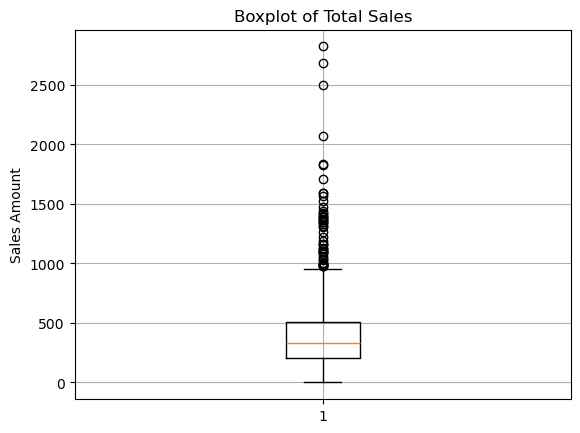

In [442]:
plt.boxplot(df2['total'].dropna())  # dropna() to avoid errors from NaNs
plt.title("Boxplot of Total Sales")
plt.ylabel("Sales Amount")
plt.grid(True)
plt.show()

In [443]:
quarterly_sales = df2.groupby(df2['date'].dt.to_period('Q'))['total'].sum().reset_index()

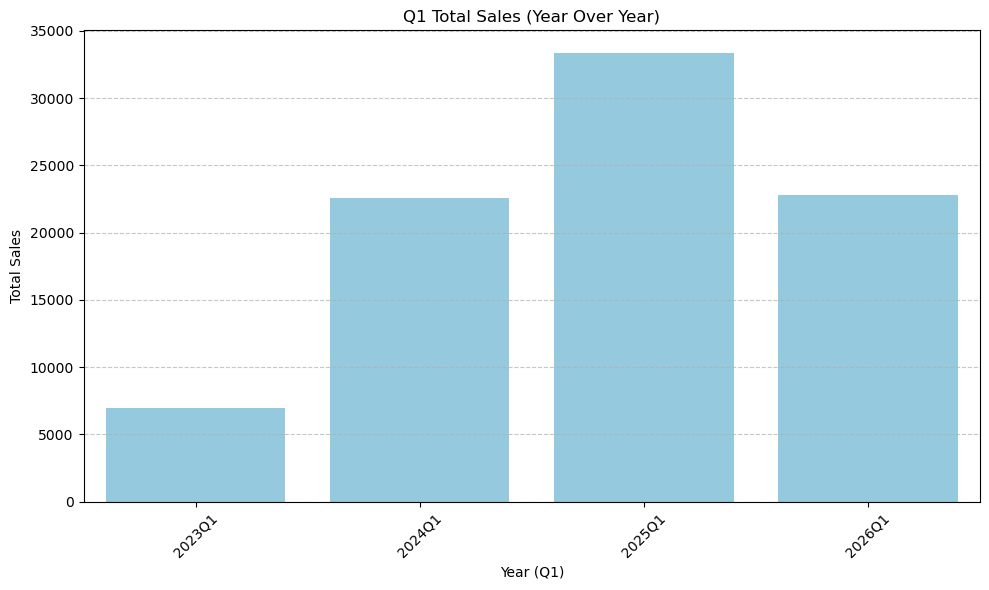

In [444]:
q1_sales = quarterly_sales[quarterly_sales['date'].dt.quarter == 1]
# 2. Plot the Bar Graph
plt.figure(figsize=(10, 6))
# We convert 'date' to a string just for plotting so the x-axis labels look clean
sns.barplot(data=q1_sales, x=q1_sales['date'].astype(str), y='total', color='skyblue')
plt.title('Q1 Total Sales (Year Over Year)')
plt.xlabel('Year (Q1)')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

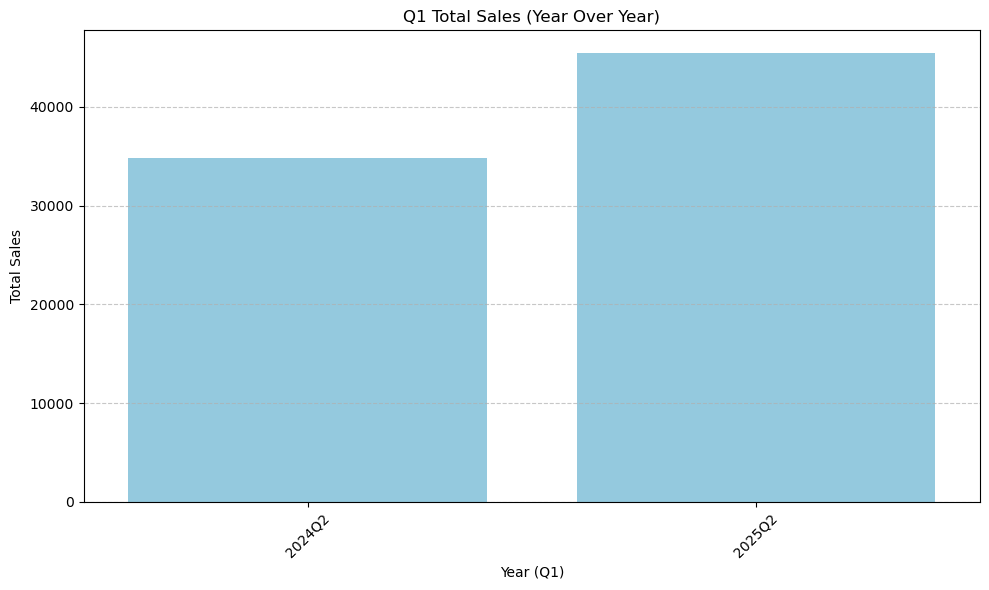

In [445]:
q2_sales = quarterly_sales[quarterly_sales['date'].dt.quarter == 2]
# 2. Plot the Bar Graph
plt.figure(figsize=(10, 6))
# We convert 'date' to a string just for plotting so the x-axis labels look clean
sns.barplot(data=q2_sales, x=q2_sales['date'].astype(str), y='total', color='skyblue')
plt.title('Q1 Total Sales (Year Over Year)')
plt.xlabel('Year (Q1)')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [446]:
df2.groupby(df2.date.dt.year).sum(numeric_only=True)

,total,total_employees_hours,total_employees,total_tips
date,,,,
2022,19484.00,510.5,0,0.00
2023,46405.00,1901.2,0,0.00
2024,144615.63,2734.7,35,1002.44
2025,168947.00,2707.5,0,1392.59
2026,22774.00,427.5,0,233.57


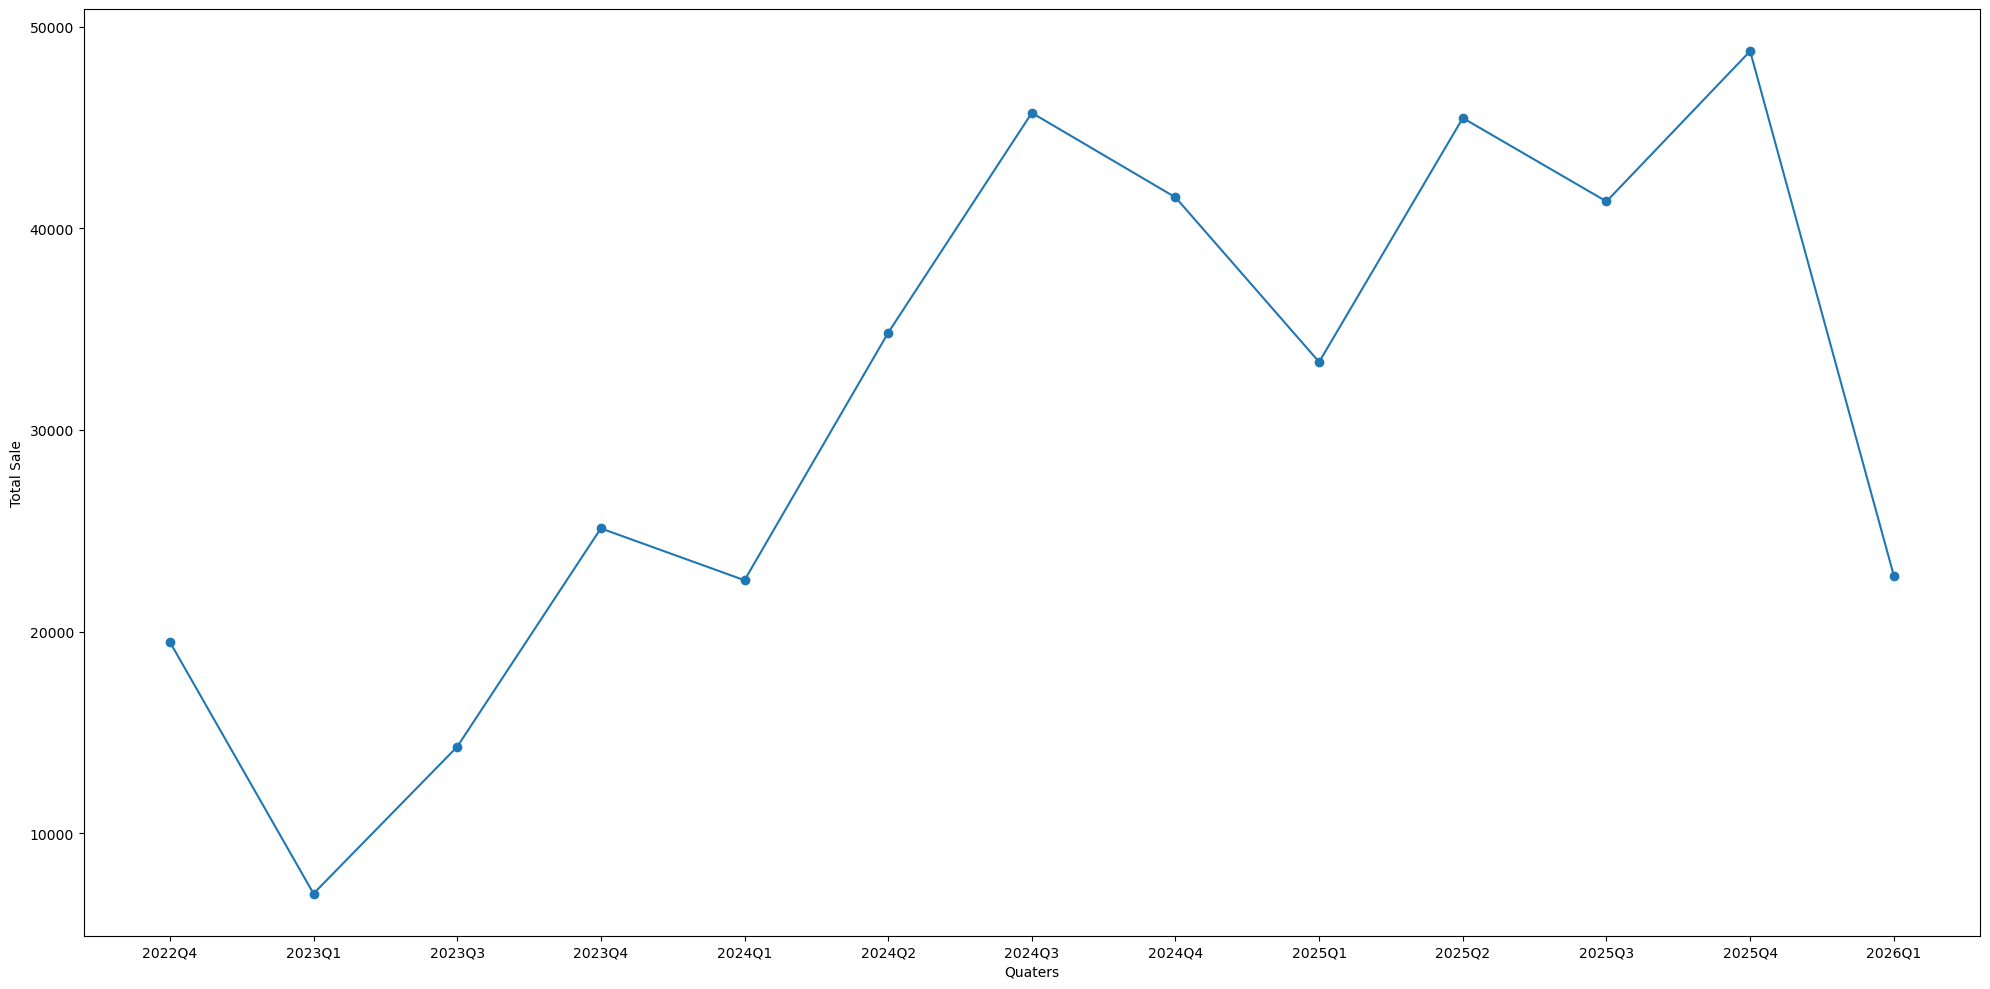

In [447]:
# plt.bar(quarterly_sales,x='Quarters',y='total sales')\
from matplotlib import markers


plt.figure(figsize=(20,10))
plt.plot(quarterly_sales['date'].astype(str), quarterly_sales['total'],marker='o')
plt.xlabel('Quaters')
plt.ylabel('Total Sale')
plt.tight_layout()
plt.show()

<Axes: >

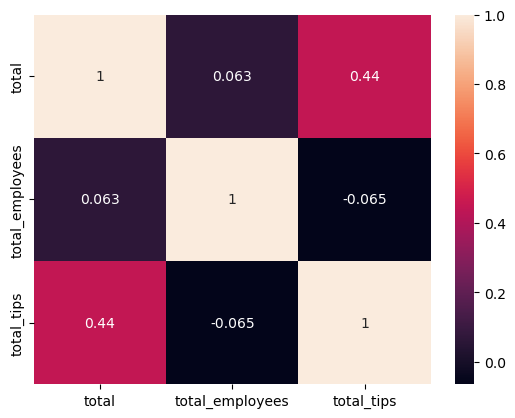

In [448]:
corelation_matrix=df2[['total','total_employees','total_tips']].corr()
sns.heatmap(corelation_matrix,annot=True)


In [449]:
df2.head()

,date,day,time,total,total_employees_hours,total_employees,total_tips
0,2022-11-01,Tuesday,11 to 8,147.0,8.5,0,0.0
1,2022-11-02,Wednesday,11 to 8,81.0,0.0,0,0.0
2,2022-11-03,Thursday,11 to 8,18.0,0.0,0,0.0
3,2022-11-04,Friday,11 to 9,27.0,9.0,0,0.0
4,2022-11-05,Saturday,10 to 9,260.0,10.0,0,0.0


In [450]:
df2.columns

Index(['date', 'day', 'time', 'total', 'total_employees_hours',
       'total_employees', 'total_tips'],
      dtype='object')

In [451]:
df['date'].max()

Timestamp('2026-02-28 00:00:00')

In [452]:
df2['month'] = df2['date'].dt.month

df2['week'] = df2['date'].dt.isocalendar().week

In [453]:
df2.head(15)

,date,day,time,total,total_employees_hours,total_employees,total_tips,month,week
0,2022-11-01,Tuesday,11 to 8,147.0,8.5,0,0.0,11,44
1,2022-11-02,Wednesday,11 to 8,81.0,0.0,0,0.0,11,44
2,2022-11-03,Thursday,11 to 8,18.0,0.0,0,0.0,11,44
3,2022-11-04,Friday,11 to 9,27.0,9.0,0,0.0,11,44
4,2022-11-05,Saturday,10 to 9,260.0,10.0,0,0.0,11,44
5,2022-11-06,Sunday,11 to 7,81.0,10.0,0,0.0,11,44
6,2022-11-07,Monday,10 to 9,306.0,9.0,0,0.0,11,45
7,2022-11-08,Tuesday,11 to 8,123.0,0.0,0,0.0,11,45
8,2022-11-09,Wednesday,11 to 8,90.0,0.0,0,0.0,11,45
9,2022-11-10,Thursday,11 to 8,108.0,0.0,0,0.0,11,45


In [454]:
df2['year'] = df2['date'].dt.year
df2['quarter'] = df2['date'].dt.quarter
df2['is_weekend'] = df2['day'].isin(['Saturday','Sunday']).astype(bool)

In [455]:
yearly_sale = df2.groupby(by= 'year').total.sum().reset_index()

In [456]:
print(yearly_sale)

   year      total
0  2022   19484.00
1  2023   46405.00
2  2024  144615.63
3  2025  168947.00
4  2026   22774.00


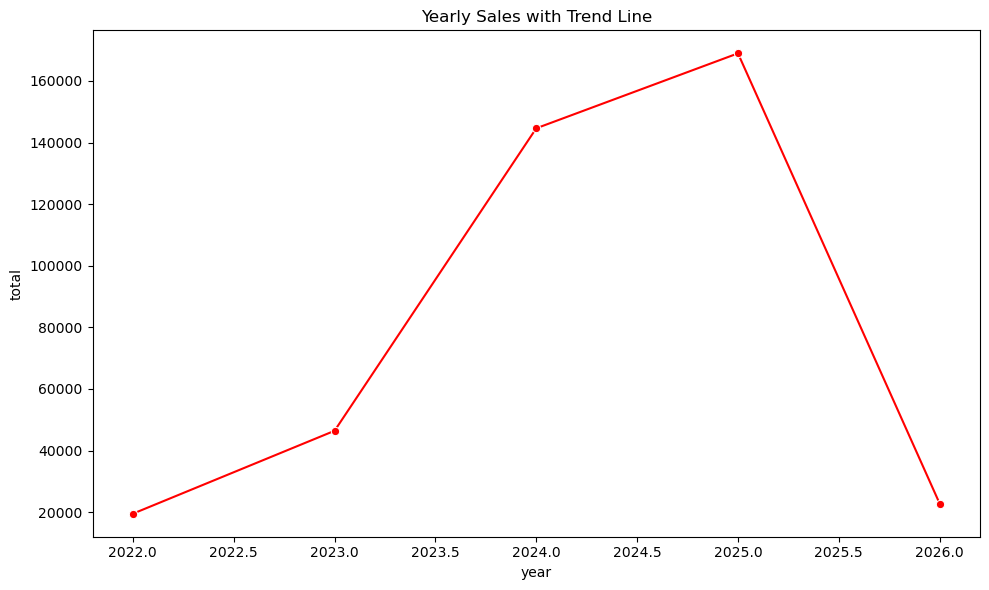

In [457]:
plt.figure(figsize=(10, 6))
# sns.barplot(data=yearly_sale, x='year', y='total', color='skyblue')
sns.lineplot(data=yearly_sale, x='year', y='total', color='red', marker='o')
plt.title("Yearly Sales with Trend Line")
plt.tight_layout()
plt.show()


In [458]:
df2.dtypes

date                     datetime64[ns]
day                              object
time                             object
total                           float64
total_employees_hours           float64
total_employees                   Int64
total_tips                      float64
month                             int32
week                             UInt32
year                              int32
quarter                           int32
is_weekend                         bool
dtype: object

In [459]:
from pandas.api.types import CategoricalDtype

day_wise_sales = df2.groupby(by='day')[['total','total_tips']].sum().reset_index()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cat_dtype = CategoricalDtype(categories=days_order, ordered=True)
day_wise_sales['day'] = day_wise_sales['day'].astype(cat_dtype)
day_wise_sales = day_wise_sales.sort_values('day')
melted = day_wise_sales.melt(id_vars='day', value_vars=['total', 'total_tips'],
                             var_name='Metric', value_name='Amount')
print(melted)

          day      Metric    Amount
0      Monday       total  47908.00
1     Tuesday       total  53537.63
2   Wednesday       total  50837.00
3    Thursday       total  49006.00
4      Friday       total  66075.00
5    Saturday       total  81363.00
6      Sunday       total  53499.00
7      Monday  total_tips    362.48
8     Tuesday  total_tips    310.11
9   Wednesday  total_tips    266.87
10   Thursday  total_tips    253.08
11     Friday  total_tips    349.39
12   Saturday  total_tips    537.00
13     Sunday  total_tips    549.67


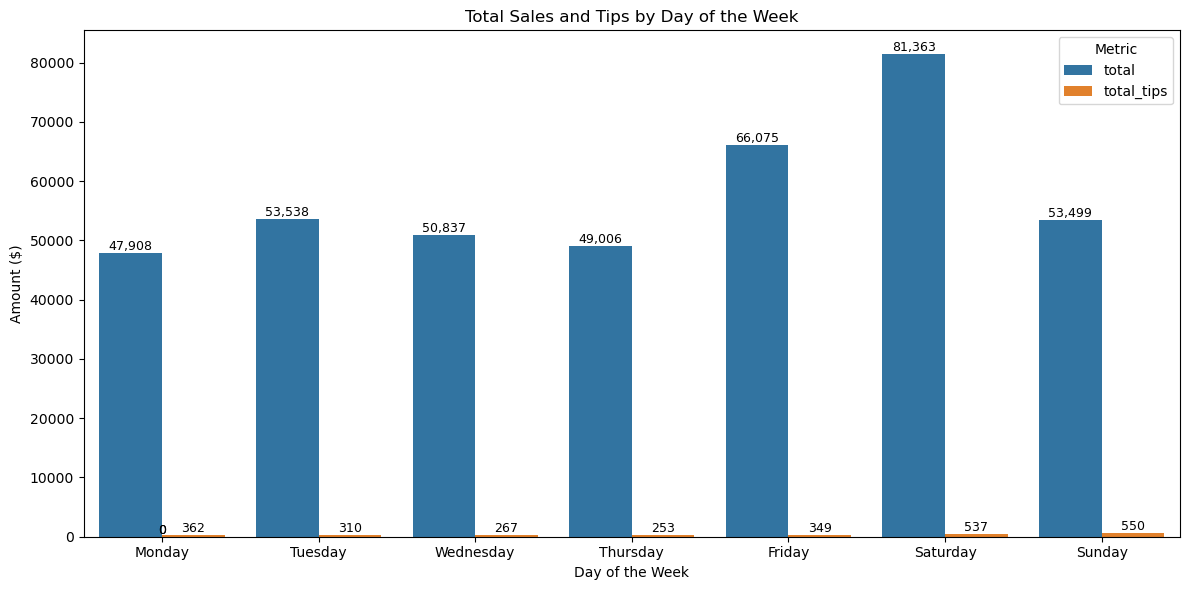

In [460]:
# Step 4: Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=melted, x='day', y='Amount', hue='Metric')

# Step 5: Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):  # skip NaNs
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height,
            s=f'{height:,.0f}',  # format number
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.title("Total Sales and Tips by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Amount ($)")
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# Calculating Moving Average

In [461]:
# # Ensure date is index
df2 = df2.sort_values("date")
df2.set_index("date", inplace=True)


In [462]:
df2['total:10_days_rolling']=df2['total'].rolling(window=10, min_periods=1).mean() 
df2['total:30_days_rolling']=df2['total'].rolling(window=30, min_periods=1).mean() 
df2['total:50_days_rolling']=df2['total'].rolling(window=50, min_periods=1).mean() 

In [463]:
df2.index.max()

Timestamp('2026-02-28 00:00:00')

<Axes: xlabel='date'>

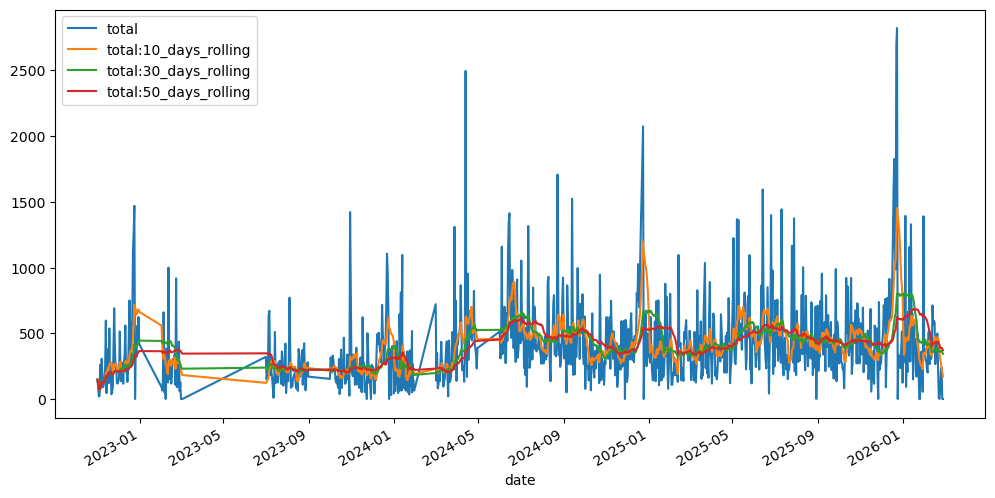

In [464]:
df2[['total','total:10_days_rolling','total:30_days_rolling','total:50_days_rolling']].plot(figsize=(12,6))

<Axes: xlabel='date'>

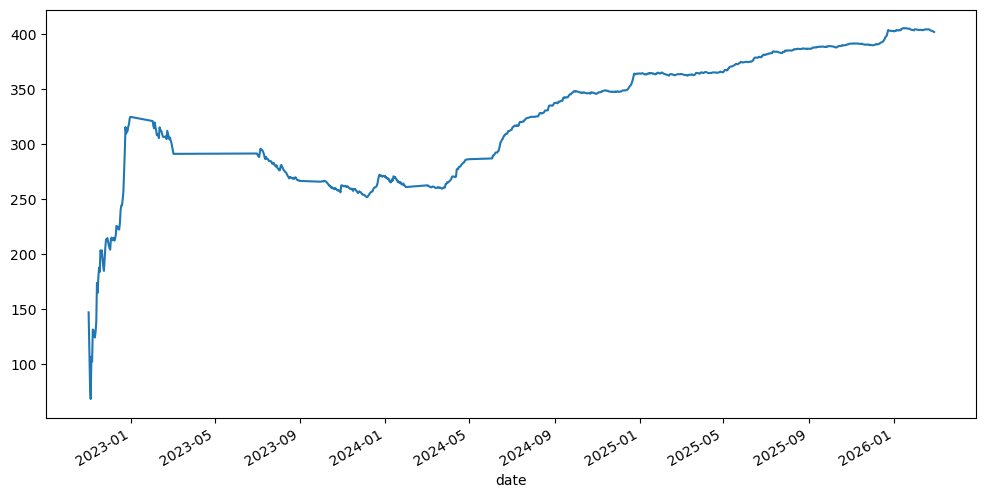

In [465]:
# Cumulative Moving Average 
df2['total'].expanding().mean().plot(figsize=(12,6))

In [466]:
df2.index.max()

Timestamp('2026-02-28 00:00:00')

# Classical Time Series Decomposition

In [467]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive = seasonal_decompose(df2['total'], model='additive', period= 7)# Model Building

In [468]:
trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

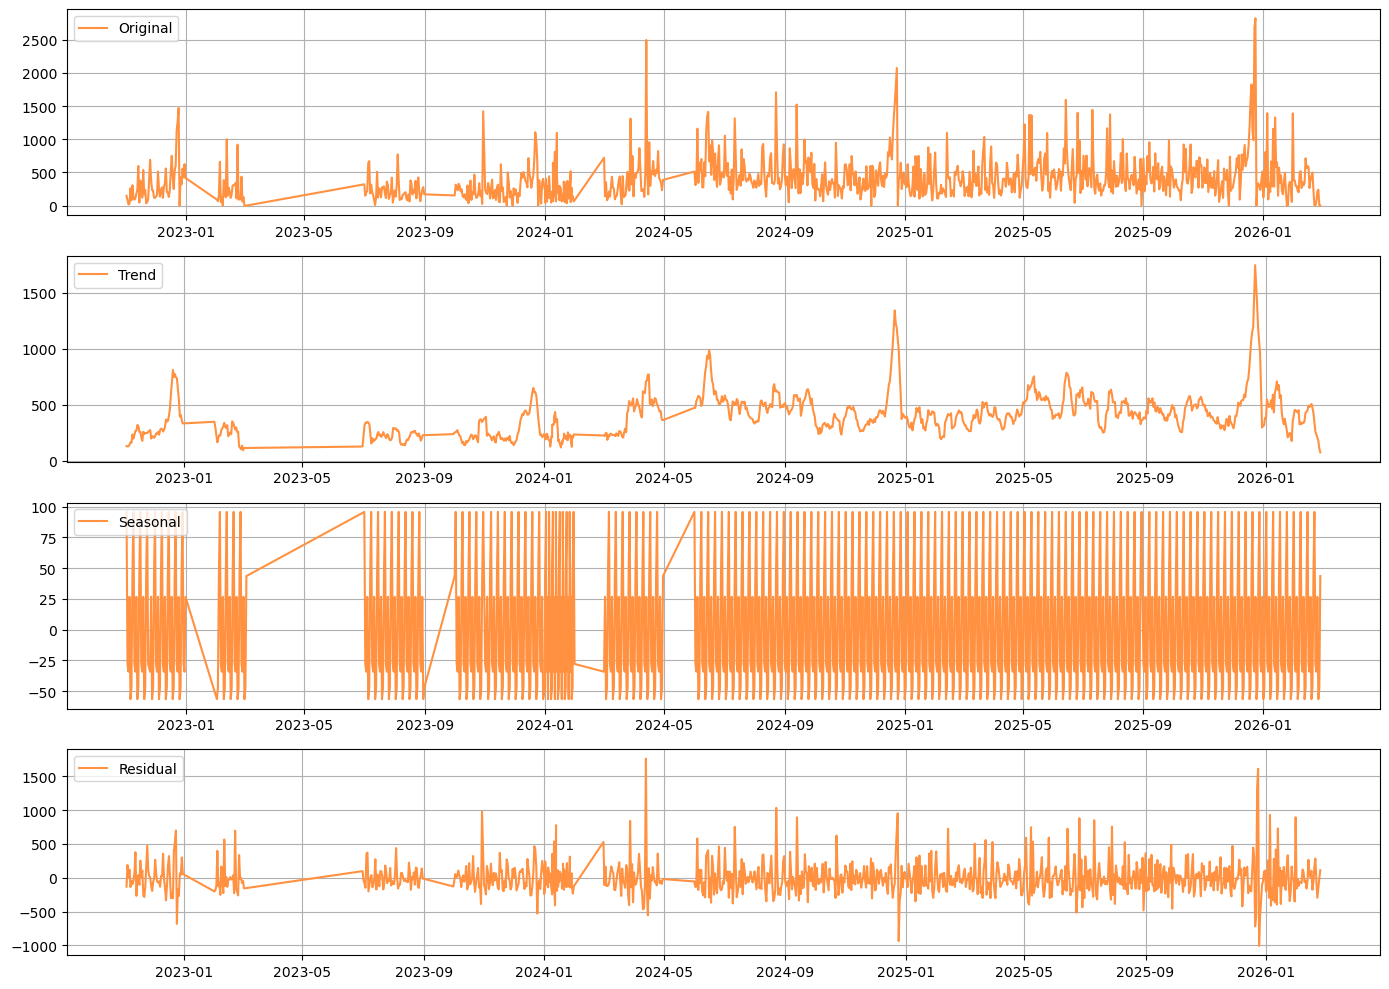

In [469]:
plt.figure(figsize= (14,10))
plt.subplot(411)
plt.plot(df2['total'], label = 'Original', color = '#FF9140')
plt.grid(True)
plt.legend(loc= 'upper left')
plt.subplot(412)
plt.grid(True)
plt.plot(trend_additive, label = 'Trend', color = '#FF9140')
plt.legend(loc= 'upper left')
plt.subplot(413)
plt.grid(True)
plt.plot(seasonal_additive, label = 'Seasonal', color = '#FF9140')
plt.legend(loc= 'upper left')
plt.subplot(414)
plt.grid(True)
plt.plot(residual_additive, label = 'Residual', color = '#FF9140')
plt.legend(loc= 'upper left')
plt.tight_layout()
plt.show()



In [470]:
df2.is_weekend = df2.is_weekend.astype('int')

In [471]:
df2[df2['total']==0]

,day,time,total,total_employees_hours,total_employees,total_tips,month,week,year,quarter,is_weekend,total:10_days_rolling,total:30_days_rolling,total:50_days_rolling
date,,,,,,,,,,,,,,
2022-12-25,Sunday,Closed,0.0,0.0,0,0.0,12,51,2022,4,1,693.2,392.666667,328.90
2023-02-07,Tuesday,11 to 8,0.0,7.5,0,0.0,2,6,2023,1,0,261.9,426.233333,350.28
2023-03-01,Wednesday,11 to 8,0.0,0.0,0,0.0,3,9,2023,1,0,227.1,247.366667,360.46
2023-03-02,Thursday,11 to 8,0.0,0.0,0,0.0,3,9,2023,1,0,192.9,233.466667,349.28
2023-03-03,Friday,11 to 9,0.0,0.0,0,0.0,3,9,2023,1,0,182.1,230.466667,345.14
2023-11-23,Thursday,11 to 8,0.0,0.0,0,0.0,11,47,2023,4,0,180.5,234.800000,221.66
2023-11-29,Wednesday,11 to 8,0.0,7.5,0,0.0,11,48,2023,4,0,155.8,243.133333,218.30
2023-12-25,Monday,Closed,0.0,0.0,0,0.0,12,52,2023,4,0,545.7,367.666667,304.82
2024-11-28,Thursday,11 to 8,0.0,0.0,0,0.0,11,48,2024,4,0,318.0,369.600000,349.30


In [473]:
df2['is_future'] = df2.index > '2026-02-28'

df2['is_closed'] = (
    (df2['total'] == 0) &
    (df2['total_employees_hours'] == 0) &
    (df2['total_employees'] == 0)
)

df2['is_suspicious_zero'] = (
    (df2['total'] == 0) &
    (df2['total_employees_hours'] > 0)
)


In [474]:
# Drop future data

df2 = df2[~df2['is_future']]

# Drop suspicious zeros
df2 = df2[~df2['is_suspicious_zero']]

df2['store_open'] = (~df2['is_closed']).astype(int)


In [475]:
df2.head()

,day,time,total,total_employees_hours,total_employees,total_tips,month,week,year,quarter,is_weekend,total:10_days_rolling,total:30_days_rolling,total:50_days_rolling,is_future,is_closed,is_suspicious_zero,store_open
date,,,,,,,,,,,,,,,,,,
2022-11-01,Tuesday,11 to 8,147.0,8.5,0,0.0,11,44,2022,4,0,147.00,147.00,147.00,False,False,False,1
2022-11-02,Wednesday,11 to 8,81.0,0.0,0,0.0,11,44,2022,4,0,114.00,114.00,114.00,False,False,False,1
2022-11-03,Thursday,11 to 8,18.0,0.0,0,0.0,11,44,2022,4,0,82.00,82.00,82.00,False,False,False,1
2022-11-04,Friday,11 to 9,27.0,9.0,0,0.0,11,44,2022,4,0,68.25,68.25,68.25,False,False,False,1
2022-11-05,Saturday,10 to 9,260.0,10.0,0,0.0,11,44,2022,4,1,106.60,106.60,106.60,False,False,False,1


## Stationarity Tests:

### 1. ADF Test

In [476]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, alpha=0.05, name="Time Series"):
    """
    Perform Augmented Dickey-Fuller test and print results.

    Parameters:
        series : pandas Series
            Time series data to test
        alpha : float
            Significance level (default 0.05)
        name : str
            Name of the series (for display)
    """
    result = adfuller(series.dropna())

    print(f"\nADF Test Results for {name}")
    print("-" * 40)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")

    if result[1] <= alpha:
        print(f"Result: Stationary (reject H₀ at α={alpha})")
    else:
        print(f"Result: Non-stationary (fail to reject H₀ at α={alpha})")


In [477]:
df2.index.max()

Timestamp('2026-02-28 00:00:00')

In [478]:
adf_test(df2['total'], name="Daily Sales")


ADF Test Results for Daily Sales
----------------------------------------
ADF Statistic: -6.9972
p-value: 0.0000
Critical Values:
  1%: -3.4370
  5%: -2.8645
  10%: -2.5683
Result: Stationary (reject H₀ at α=0.05)


### 2. KPSS Test



In [479]:
from statsmodels.tsa.stattools import kpss

def kpss_test(series, regression='ct', alpha=0.05, name="Time Series"):
    """
    Perform KPSS test and print results.

    Parameters:
        series : pandas Series
            Time series data to test
        regression : str
            'c'  = constant (level stationarity)
            'ct' = constant + trend (trend stationarity)
            'n'  = no constant, no trend
        alpha : float
            Significance level (default 0.05)
        name : str
            Name of the series (for display)
    """
    statistic, p_value, lags, critical_values = kpss(series.dropna(), regression=regression)

    print(f"\nKPSS Test Results for {name}")
    print("-" * 40)
    print(f"KPSS Statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.4f}")
    print("Critical Values:")
    for key, value in critical_values.items():
        print(f"  {key}: {value:.4f}")

    if p_value <= alpha:
        print(f"Result: NON-stationary (reject H₀ at α={alpha})")
    else:
        print(f"Result: Stationary (fail to reject H₀ at α={alpha})")


In [480]:
df2.index.max()

Timestamp('2026-02-28 00:00:00')

In [481]:
kpss_test(df2['total'], regression='ct', name="Daily Sales")


KPSS Test Results for Daily Sales
----------------------------------------
KPSS Statistic: 0.1605
p-value: 0.0380
Critical Values:
  10%: 0.1190
  5%: 0.1460
  2.5%: 0.1760
  1%: 0.2160
Result: NON-stationary (reject H₀ at α=0.05)


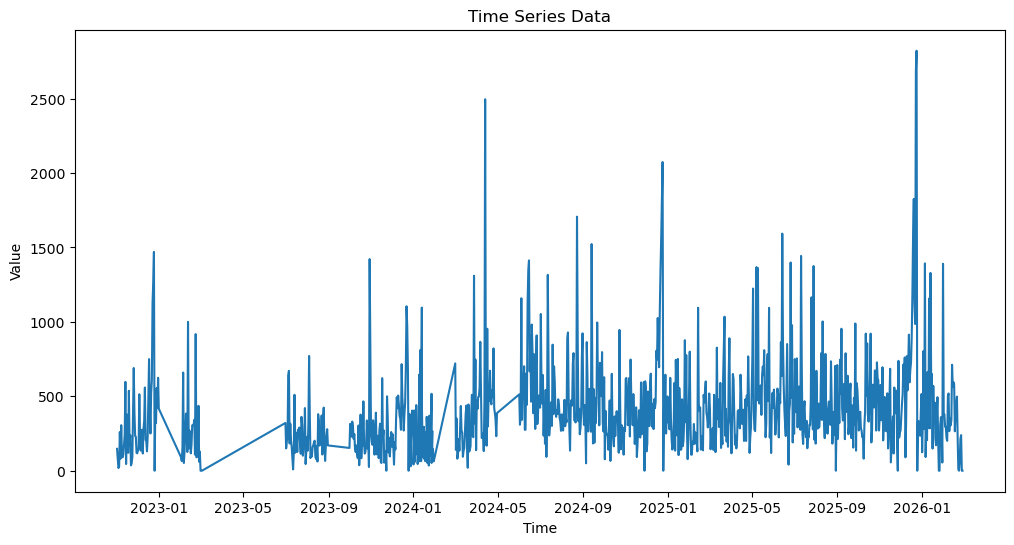

KS statistic for strict stationarity: 0.21694188376753507
KS p-value for strict stationarity: 9.79323741108493e-11


In [482]:
# Check if the data is strict stationary or not

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

def ks_test_stationarity(data):
   split = len(data) // 2
   first_half = data[:split]
   second_half = data[split:]
   statistic, p_value = ks_2samp(first_half, second_half)
   return statistic, p_value


# Perform the KS test for stationarity
ks_stat_strict, ks_pvalue_strict = ks_test_stationarity(df2['total'])

# Plotting the series
plt.figure(figsize=(12, 6))
plt.plot(df2['total'])
plt.title('Time Series Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()
print(f"KS statistic for strict stationarity: {ks_stat_strict}")
print(f"KS p-value for strict stationarity: {ks_pvalue_strict}")

In [483]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [484]:
df2['weekly_total_diff']= df2['total']-df2['total'].shift(7) # as we can check how did this week perform compared to previous week.


In [485]:
adf_test(df2['weekly_total_diff'], name="Weekly Differenced Sales Data")


ADF Test Results for Weekly Differenced Sales Data
----------------------------------------
ADF Statistic: -10.6080
p-value: 0.0000
Critical Values:
  1%: -3.4371
  5%: -2.8645
  10%: -2.5684
Result: Stationary (reject H₀ at α=0.05)


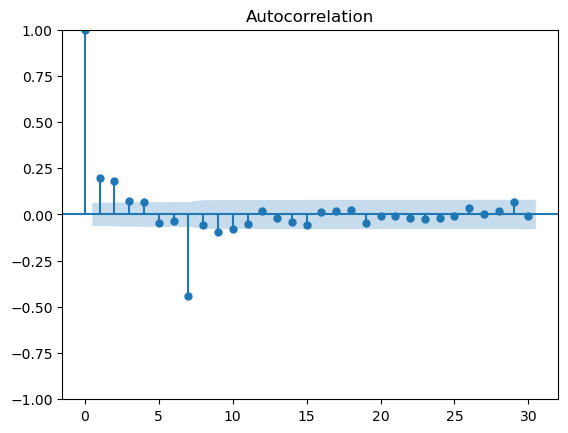

In [486]:
# auto corrleation plot
acf = plot_acf(df2['weekly_total_diff'].dropna())

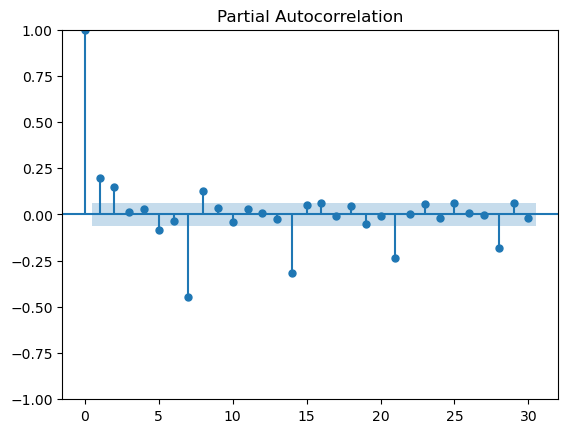

In [487]:
# Partial auto corrleation plot 
#With PACF we find out AR
#With ACF we find out MA
pacf = plot_pacf(df2['weekly_total_diff'].dropna())

In [488]:
df2

,day,time,total,total_employees_hours,total_employees,total_tips,month,week,year,quarter,is_weekend,total:10_days_rolling,total:30_days_rolling,total:50_days_rolling,is_future,is_closed,is_suspicious_zero,store_open,weekly_total_diff
date,,,,,,,,,,,,,,,,,,,
2022-11-01,Tuesday,11 to 8,147.0,8.5,0,0.00,11,44,2022,4,0,147.00,147.000000,147.00,False,False,False,1,NaN
2022-11-02,Wednesday,11 to 8,81.0,0.0,0,0.00,11,44,2022,4,0,114.00,114.000000,114.00,False,False,False,1,NaN
2022-11-03,Thursday,11 to 8,18.0,0.0,0,0.00,11,44,2022,4,0,82.00,82.000000,82.00,False,False,False,1,NaN
2022-11-04,Friday,11 to 9,27.0,9.0,0,0.00,11,44,2022,4,0,68.25,68.250000,68.25,False,False,False,1,NaN
2022-11-05,Saturday,10 to 9,260.0,10.0,0,0.00,11,44,2022,4,1,106.60,106.600000,106.60,False,False,False,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,Tuesday,11 to 8,64.0,5.0,0,0.00,2,9,2026,1,0,306.90,360.466667,387.70,False,False,False,1,-201.0
2026-02-25,Wednesday,11 to 8,213.0,6.0,0,5.43,2,9,2026,1,0,268.70,367.566667,390.12,False,False,False,1,-168.0
2026-02-26,Thursday,11 to 8,239.0,0.0,0,0.00,2,9,2026,1,0,234.50,365.266667,388.26,False,False,False,1,-208.0


## Seasonality Analysis and Anamoly Detection

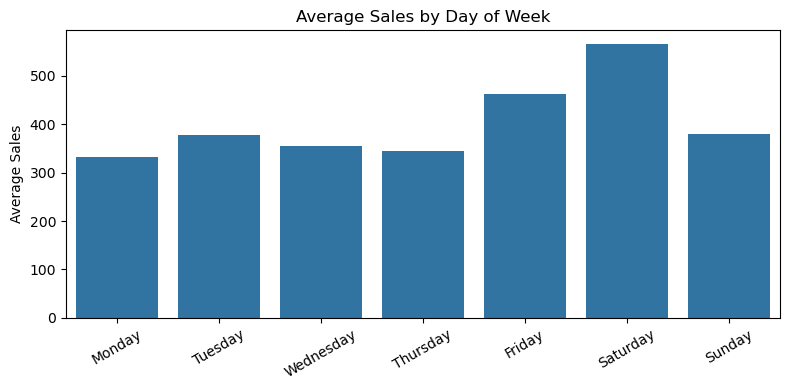

In [489]:
# Sales by Day of Week
df2['day_of_week'] = df2.index.day_name()

dow_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

avg_dow = (
    df2.groupby('day_of_week')['total']
       .mean()
       .reindex(dow_order)
)

plt.figure(figsize=(8,4))
sns.barplot(x=avg_dow.index, y=avg_dow.values)
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Sales')
plt.xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


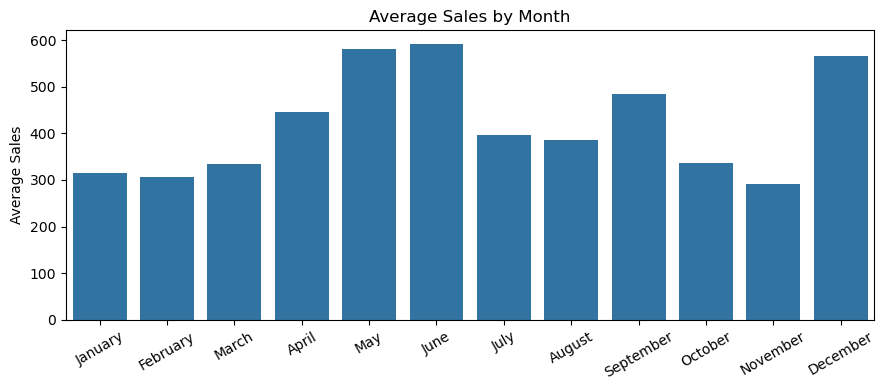

In [490]:
# Sale by Month
df2['month'] = df2.index.month
df2['month_name'] = df2.index.month_name()

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

avg_month = (
    df2.groupby('month_name')['total']
       .mean()
       .reindex(month_order)
)

plt.figure(figsize=(9,4))
sns.barplot(x=avg_month.index, y=avg_month.values)
plt.title('Average Sales by Month')
plt.ylabel('Average Sales')
plt.xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


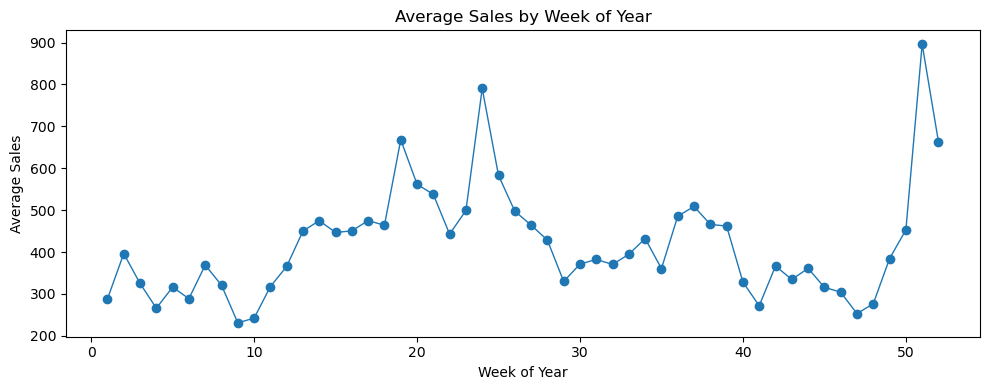

In [491]:
df2['week_of_year'] = df2.index.isocalendar().week

avg_week = (
    df2.groupby('week_of_year')['total']
       .mean()
)

plt.figure(figsize=(10,4))
plt.plot(avg_week.index, avg_week.values, marker='o', linewidth=1)
plt.title('Average Sales by Week of Year')
plt.ylabel('Average Sales')
plt.xlabel('Week of Year')
plt.tight_layout()
plt.show()


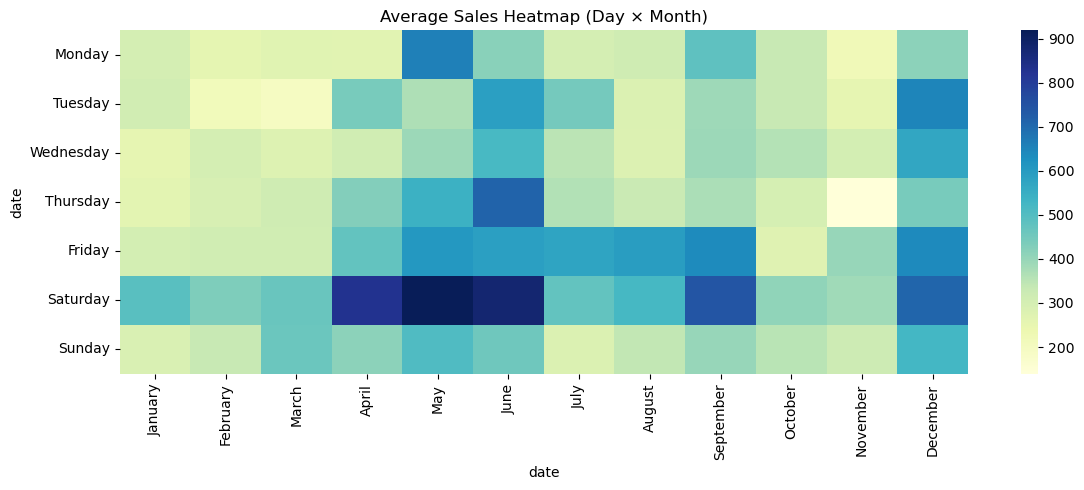

In [492]:
pivot = df2.pivot_table(
    values='total',
    index=df2.index.day_name(),
    columns=df2.index.month_name(),
    aggfunc='mean'
).reindex(index=dow_order, columns=month_order)

plt.figure(figsize=(12,5))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Average Sales Heatmap (Day × Month)')
plt.tight_layout()
plt.show()


In [493]:
df2.index.max()

Timestamp('2026-02-28 00:00:00')

In [494]:
from pathlib import Path

# Save cleaned EDA dataframe for model training notebook
out_candidates = [Path('../datasets/eda_cleaned.csv'), Path('datasets/eda_cleaned.csv')]
out_path = next((p for p in out_candidates if p.parent.exists()), out_candidates[0])

df2_to_save = df2.copy().reset_index()
df2_to_save.to_csv(out_path, index=False)
print(f'Saved cleaned data: {out_path} | rows={len(df2_to_save)}, cols={len(df2_to_save.columns)}')


Saved cleaned data: ../datasets/eda_cleaned.csv | rows=999, cols=23


In [495]:
df2.index.max()

Timestamp('2026-02-28 00:00:00')